# 9. Ray-traced voxels

`sylva.voxels` traces every pulse through a voxel grid and estimates the
attenuation coefficient λ of each voxel from how far pulses got, then plant area
density as λ / G. It follows AMAPVox and the rayvoxel tool; see the
[guide](../guide/voxels.md) for the estimators.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import Shots, voxels

## Tracing a real tile

The Litchfield pulses, with the echoes' `classification` so the terrain can be
left out of the plant area. `occlusion=True` also records what the pulses never
reached.

In [2]:
shots = Shots.load(DATA / "litch_tile_shots.parquet")
grid = voxels.ray_voxelize(
    shots, voxel_size=0.5, bounds=((0, 0, 0), (20, 20, 18)),
    ground_class=2, leaf_classes=[4], attenuation=["fpl", "ppl"], occlusion=True,
)
print(grid)
print("raw fields:", ", ".join(grid.fields[:10]), "...")

RayVoxelGrid(40x40x36 @ 0.5 m)
raw fields: num_hits, num_beams, num_beams_occluded, num_unbound_rays, num_miss_rays, num_hit_leaf, num_hit_wood, num_hit_plant, num_beams_weighted, path_length ...


`state` is 0 unobserved, 1 occluded (only reached behind a last echo),
2 empty, 3 filled. Arrays are `(nz, ny, nx)`. Here 97 % of the tile was
observed and 3 % is occluded, which is what many scan positions buy you.

{'unobserved': '0.0%', 'occluded': '2.9%', 'empty': '80.1%', 'filled': '17.0%'}
{'observed': 0.971, 'occluded': 0.029, 'unobserved': 0.0, 'top': 17.75}


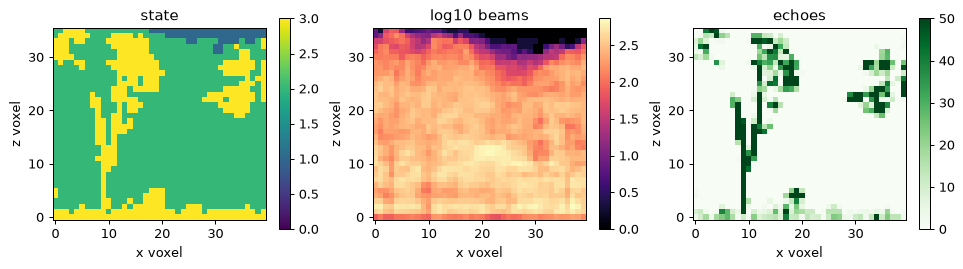

In [3]:
state = grid.state
names = ["unobserved", "occluded", "empty", "filled"]
print({n: f"{np.mean(state == i):.1%}" for i, n in enumerate(names)})
print({k: round(v, 3) for k, v in grid.occlusion_profile()["total"].items()})
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
j = 15                                        # the row of voxels at y = 7.5 m
for a, (v, title, kw) in zip(ax, [
        (state[:, j, :], "state", dict(cmap="viridis", vmin=0, vmax=3)),
        (np.log10(grid.num_beams[:, j, :] + 1), "log10 beams", dict(cmap="magma")),
        (grid.num_hits[:, j, :], "echoes", dict(cmap="Greens", vmax=50))]):
    im = a.imshow(v, origin="lower", **kw); a.set(title=title, xlabel="x voxel", ylabel="z voxel")
    fig.colorbar(im, ax=a, shrink=0.8)

## Attenuation and area density

FPL and PPL agree where voxels are well sampled and diverge where they are
not, which is the useful diagnostic. The profile below is the *tile's*, not the
plot's: because every ray was clipped at the tile boundary, the pulses crossing
the upper canopy are few and near-horizontal, and λ there is estimated from
short path lengths, which biases PAD upward. The plot value for Litchfield,
from whole scans with their true origins, is PAI 1.4 (see the [canopy
benchmark](../benchmarks/canopy.md)); this tile gives several times that. Use a
`min_beams` threshold, and read the profile's shape rather than its
magnitude.

median beams per voxel by layer: [128 410 373 251 178  73]


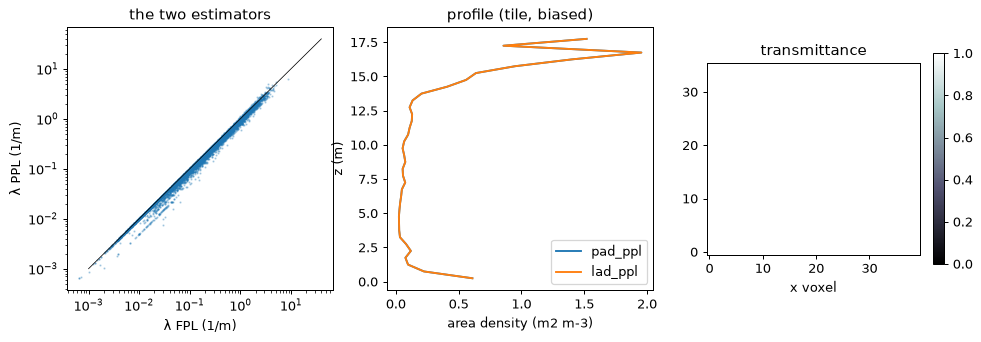

In [4]:
ok = (grid.num_beams >= 100) & (grid.num_hits > 0)
z = grid.z_levels() + 0.25
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].loglog(grid.attenuation_fpl[ok], grid.attenuation_ppl[ok], ".", ms=1.5, alpha=0.3)
ax[0].plot([1e-3, 40], [1e-3, 40], "k", lw=0.6)
ax[0].set(xlabel="λ FPL (1/m)", ylabel="λ PPL (1/m)", title="the two estimators")
for name in ("pad_ppl", "lad_ppl"):
    ax[1].plot(grid.profile(name, min_beams=100), z, label=name)
ax[1].set(xlabel="area density (m2 m-3)", ylabel="z (m)", title="profile (tile, biased)"); ax[1].legend()
im = ax[2].imshow(grid.transmittance[:, j, :], origin="lower", cmap="bone", vmin=0, vmax=1)
ax[2].set(title="transmittance", xlabel="x voxel"); fig.colorbar(im, ax=ax[2], shrink=0.8)
print("median beams per voxel by layer:", np.median(grid.num_beams, axis=(1, 2)).astype(int)[::6])

## Checking the estimators against a known scene

To see whether the numbers are right, the scene has to be known. Four
synthetic scans of a scene with a known leaf area: the estimate should be the
right size, and low, because the pseudo-scanner sees each leaf disc through
only a few points.

In [5]:
scene = synthetic.forest()
positions = [(3, 3), (17, 3), (3, 17), (17, 17), (10, 10)]
sim = Shots.concatenate([
    synthetic.scan(scene, origin=(x, y, synthetic.terrain_height(x, y) + 1.5), resolution_deg=0.2)
    for x, y in positions])
sim_grid = voxels.ray_voxelize(sim, 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2,
                               leaf_classes=[4], wood_classes=[5], attenuation=["fpl", "ppl"])
pai = float(np.nansum(sim_grid.profile("pad_ppl", min_beams=20)) * 0.5)
lai = float(np.nansum(sim_grid.profile("lad_ppl", min_beams=20)) * 0.5)
print(f"PAI {pai:.2f}  LAI {lai:.2f}  true LAI of the scene {synthetic.leaf_area(scene) / 20**2:.2f}")

PAI 0.23  LAI 0.17  true LAI of the scene 0.30


## Leaf angles

With `inclination=True`, normals of the echoes give an inclination angle
distribution per tree, and G is integrated over it and over the tree's beam
zeniths instead of assuming a spherical distribution. The synthetic leaves are
randomly oriented discs, so the result should be close to spherical with
G ≈ 0.5.

tree 1: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 2: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.50
tree 3: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 4: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.48


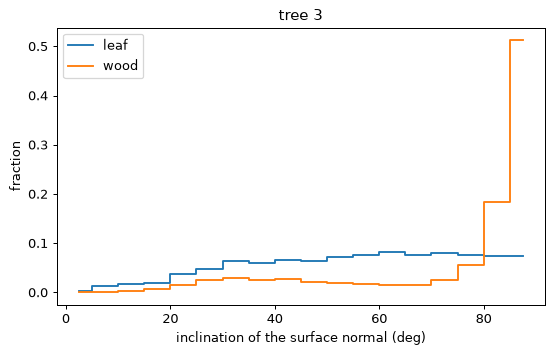

In [6]:
inc = voxels.ray_voxelize(sim, 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2,
                          leaf_classes=[4], wood_classes=[5], inclination=True)
for tid, t in inc.tree_iad.items():
    print(f"tree {tid}: leaves {t['liad_de_wit']:12s} G_leaf {t['g_leaf']:.2f}   "
          f"wood {t['wiad_de_wit']:12s} G_wood {t['g_wood']:.2f}")
t = inc.tree_iad[3]
plt.step(np.degrees(t["bin_centres"]), t["liad"], where="mid", label="leaf")
plt.step(np.degrees(t["bin_centres"]), t["wiad"], where="mid", label="wood")
plt.gca().set(xlabel="inclination of the surface normal (deg)", ylabel="fraction", title="tree 3"); plt.legend();

## Wood volume, files and streaming

QSM cylinders can be rasterised into the same grid; `write` produces an AMAPVox `.vox` file or a text table; and a shots file is voxelised without being loaded.

In [7]:
from sylva import qsm
tree3 = scene[scene.attrs["tree_id"] == 3]
model = qsm.build_qsm(tree3[tree3.attrs["classification"] == 5], base_xy=(8.0, 15.0))
sim_grid.add_wood_volume(model)
print(f"wood volume in the grid {sim_grid.wood_volume.sum():.3f} m3 of {model.total_volume:.3f} m3 in the QSM")

n = grid.write("tile.vox")
print(n, "voxels written to tile.vox")
streamed = voxels.ray_voxelize(DATA / "litch_tile_shots.parquet", 0.5, ((0, 0, 0), (20, 20, 18)),
                               ground_class=2, leaf_classes=[4])
print("streamed from the file:", streamed,
      "- same echo count:", int(streamed.num_hits.sum()) == int(grid.num_hits.sum()))

wood volume in the grid 1.083 m3 of 1.083 m3 in the QSM
57600 voxels written to tile.vox


streamed from the file: RayVoxelGrid(40x40x36 @ 0.5 m) - same echo count: True
